C:\Users\eeee\AppData\Local\Temp\ipykernel_18316\1298211501.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.index, x=category_counts.values, palette="Set2")


Saved: figures\feature_inventory.png


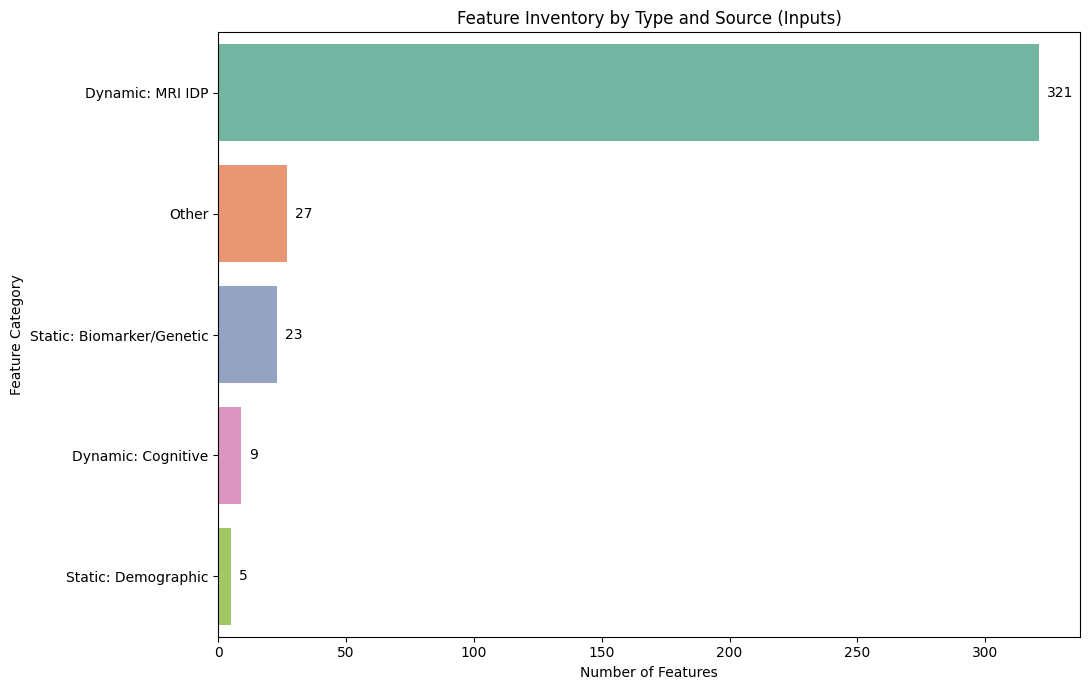

Model feature dimension (excluding ['RID', 'Month', 'MMSE', 'DX']): 385
Counts by category:
 Dynamic: MRI IDP             321
Other                         27
Static: Biomarker/Genetic     23
Dynamic: Cognitive             9
Static: Demographic            5
Name: count, dtype: int64


In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- CONFIG --------------------
# Path to the cleaned ADNI time-series dataset
# (left empty for GitHub; users should fill in their own local path)
DATA_PATH = r""

# Identifier columns (not used as model inputs)
ID_COLS = ["RID", "Month"]

# Supervised learning targets to exclude from model inputs
EXCLUDE_FROM_MODEL = ["MMSE", "DX"]

# Baseline variables explicitly excluded from static features
EXCLUDE_BL_FROM_STATIC = {"MMSE_bl"}

# Output settings
OUT_DIR = "figures"
BASE_NAME = "feature_inventory"
DPI = 450
# ------------------------------------------------

# --- Load data and construct candidate model feature set ---
df = pd.read_csv(DATA_PATH)

# Remove identifier columns
all_cols = [c for c in df.columns if c not in ID_COLS]

# Remove supervised targets from model inputs
model_cols = [c for c in all_cols if c not in EXCLUDE_FROM_MODEL]

# --- Static feature definition rules ---
# Exact static feature names
STATIC_EXACTS = {
    "AGE", "SITE", "PTGENDER", "PTEDUCAT", "PTETHCAT", "PTRACCAT",
    "PTMARRY", "ICV", "ICV_bl"
}

# Pattern-based static feature rules
STATIC_PATTERNS = [
    r"^APOE.*",          # APOE genotype
    r".*EDUC.*",         # Education-related variables
    r".*_bl$",           # Baseline variables (unless explicitly excluded)
]

# Uppercase sets for robust matching
EXCLUDE_BL_SET = {x.upper() for x in EXCLUDE_BL_FROM_STATIC}
STATIC_EXACTS_UP = {x.upper() for x in STATIC_EXACTS}

def is_static(col: str) -> bool:
    """
    Determine whether a feature is static across time.
    Static features do not change across longitudinal visits.
    """
    u = col.upper()

    # Explicit exclusions
    if u in EXCLUDE_BL_SET:
        return False

    # Exact-name static features
    if u in STATIC_EXACTS_UP:
        return True

    # Pattern-based static features
    return any(re.match(pat, col, flags=re.IGNORECASE) for pat in STATIC_PATTERNS)

# --- Feature categorization rules ---
# MRI-derived imaging phenotype (IDP) prefix pattern
MRI_PREFIX_RE = re.compile(r"^ST\d{2,3}", flags=re.IGNORECASE)

def categorize_feature(col: str) -> str:
    """
    Assign each feature to a semantic category
    (Static or Dynamic, grouped by data source).
    """
    u = col.upper()

    # ---------- Static features ----------
    if is_static(col):
        if any(k in u for k in ["AGE", "EDU", "GENDER", "SEX", "SITE",
                                "PTETHCAT", "PTRACCAT", "PTMARRY"]):
            return "Static: Demographic"
        if "APOE" in u or "ICV" in u or u.endswith("_BL"):
            return "Static: Biomarker/Genetic"
        return "Static: Other"

    # ---------- Dynamic features ----------
    # Cognitive assessments (excluding supervised targets)
    if any(k in u for k in ["ADAS", "CDR", "FAQ", "MOCA", "RAVLT"]) and u not in {"MMSE", "DX"}:
        return "Dynamic: Cognitive"

    # MRI-derived imaging phenotypes (FreeSurfer-style features)
    if (
        MRI_PREFIX_RE.match(col)
        or u.endswith("_VOL")
        or u.endswith("_THK")
        or "SURFAREA" in u
        or "MEANCURV" in u
        or "GAUSCURV" in u
        or "FOLDIND" in u
        or u.startswith(("LH_", "RH_", "CTX_", "SUBCORT_",
                          "HIPPO", "AMYGD", "VENT", "CEREB"))
    ):
        return "Dynamic: MRI IDP"

    # Fluid or molecular biomarkers
    if any(k in u for k in ["ABETA", "AΒ", "TAU", "PTAU", "CSF", "PLASMA", "BIOMARK"]):
        return "Dynamic: Biomarker"

    # Fallback category
    return "Other"

# --- Count features by category ---
cats = [categorize_feature(c) for c in model_cols]
category_counts = pd.Series(cats).value_counts()

# --- Visualization (seaborn bar plot) ---
plt.figure(figsize=(11, 7))
sns.barplot(
    y=category_counts.index,
    x=category_counts.values,
    palette="Set2"
)

plt.xlabel("Number of Features")
plt.ylabel("Feature Category")
plt.title("Feature Inventory by Type and Source (Model Inputs)")

# Annotate bar values
for i, v in enumerate(category_counts.values):
    plt.text(v + max(category_counts.values) * 0.01, i, str(int(v)), va="center")

plt.tight_layout()

# Save figure
os.makedirs(OUT_DIR, exist_ok=True)
out_path = os.path.join(OUT_DIR, f"{BASE_NAME}.png")
plt.savefig(out_path, dpi=DPI, bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()

# --- Summary statistics ---
static_cols = [c for c in model_cols if is_static(c)]
dynamic_cols = [c for c in model_cols if c not in static_cols]

print(f"Model feature dimension (excluding {ID_COLS + EXCLUDE_FROM_MODEL}): {len(model_cols)}")
print("Counts by category:\n", category_counts.sort_values(ascending=False))
